In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats

In [2]:
# ====================== Data Loading ======================

url = "https://drive.google.com/uc?id=16FkxyuMJjLKgd9D6TwoXNIlIZL9hsQTA"
df = pd.read_csv(url)

In [3]:
df.head()

,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     19998 non-null  object
 1   timestamp   19998 non-null  object
 2   test_group  19998 non-null  object
 3   conversion  19998 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 625.1+ KB


In [5]:
# ====================== Number of users per group ======================

users = df['test_group'].value_counts()
users

,count
test_group,
a,10013
b,9985


In [6]:
# ====================== Number of conversions ======================

conversions = df.groupby('test_group')['conversion'].sum()
conversions

,conversion
test_group,
a,611
b,889


In [7]:
# ====================== Conversion Rate (CR) ======================
cr = (conversions / users * 100).round(2)
cr

,0
test_group,
a,6.1
b,8.9


In [8]:
# ====================== Test dates and duration ======================

df['timestamp'] = pd.to_datetime(df['timestamp'])
start_date = df['timestamp'].min()
end_date = df['timestamp'].max()
duration = (end_date - start_date).days

print(f"\nStart Date: {start_date.date()}")
print(f"End Date: {end_date.date()}")
print(f"Test Duration: {duration} days")


Start Date: 2023-07-03
End Date: 2023-07-25
Test Duration: 21 days


In [9]:
# ============== Data preparation for statistical testing ====================

conv_A = conversions['a']
conv_B = conversions['b']
n_A = users['a']
n_B = users['b']

print(f"\nGroup A: {n_A} users, {conv_A} conversions")
print(f"Group B: {n_B} users, {conv_B} conversions")


Group A: 10013 users, 611 conversions
Group B: 9985 users, 889 conversions


In [10]:
# ======================  Statistical Test (Z-test for proportions) ======================

z_stat, p_value = proportions_ztest(
    count=[conv_B, conv_A],
    nobs=[n_B, n_A],
    alternative='larger'
)

print(f"Z-statistic: {round(z_stat,2)}, P-value: {round(p_value,3)}")

Z-statistic: 7.52, P-value: 0.0


In [11]:
# Hypothesis testing

alpha = 0.05

if p_value < alpha:
    print("Reject H0. The conversion rate in Group B is statistically significantly higher.")
else:
    print("Failed to reject H0.")

Reject H0. The conversion rate in Group B is statistically significantly higher.


In [12]:
# ======================  Statistical Test (Chi-squared) ======================

# Creating a contingency table of observed frequencies
# Rows: groups (A, B), Columns: result (1 - purchased, 0 - didn't purchase)

observed = pd.crosstab(df['test_group'].values, df['conversion'].values)

print("Contingency Table (Observed Frequencies):")
print(observed)

print(stats.chi2_contingency(observed))

Contingency Table (Observed Frequencies):
col_0     0    1
row_0           
a      9402  611
b      9096  889
Chi2ContingencyResult(statistic=np.float64(56.14249485320227), pvalue=np.float64(6.740440730497395e-14), dof=1, expected_freq=array([[9261.94989499,  751.05010501],
       [9236.05010501,  748.94989499]]))


In [13]:
# Running the Chi-squared test
statistic, pvalue, dof, expected_values = stats.chi2_contingency(observed)


print(f'Chi-squared statistic: {round(statistic, 2)}')
print(f'p-value: {pvalue}')

# Hypothesis Testing (alpha = 0.05)
alpha = 0.05
if pvalue < alpha:
    print('The difference is statistically significant; the null hypothesis is rejected.')
else:
    print('The difference is insignificant; failed to reject the null hypothesis.')

Chi-squared statistic: 56.14
p-value: 6.740440730497395e-14
The difference is statistically significant; the null hypothesis is rejected.


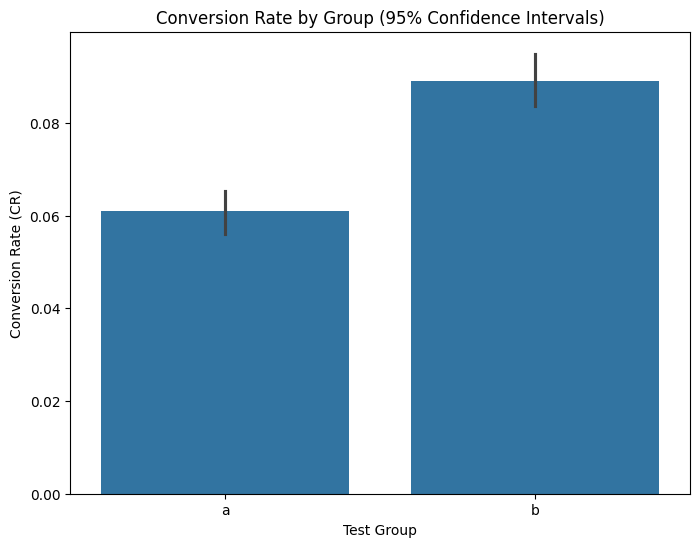

In [14]:
# ======================  Visualization ======================

plt.figure(figsize=(8, 6))

sns.barplot(x='test_group', y='conversion', data=df, errorbar=('ci', 95))
plt.title('Conversion Rate by Group (95% Confidence Intervals)')
plt.xlabel('Test Group')
plt.ylabel('Conversion Rate (CR)')

plt.savefig('conversion_rate.png')

plt.show()

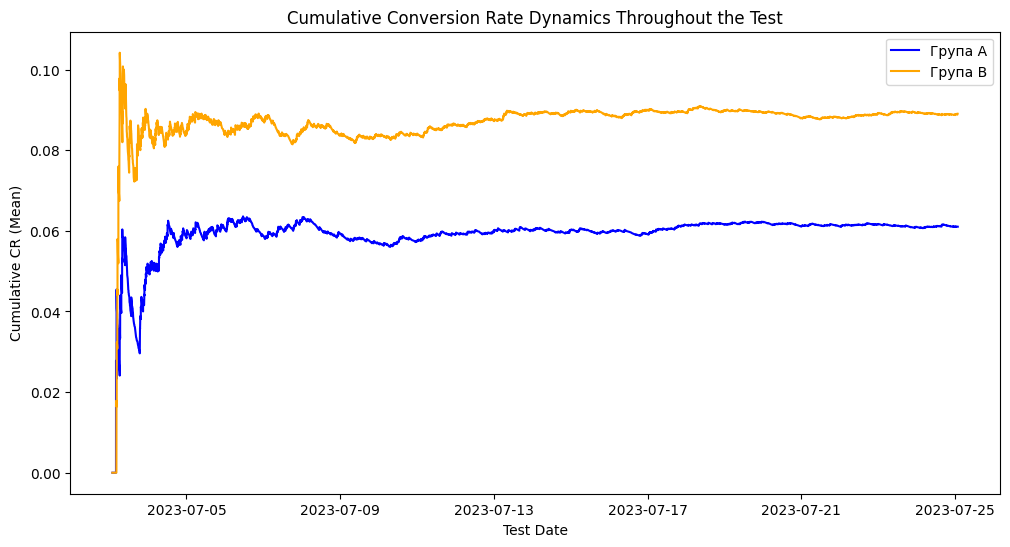

In [15]:
# ====================== BONUS: Cumulative conversion rate over time  ======================

# Sorting data by timestamp
df = df.sort_values('timestamp')

# Splitting into groups and calculating cumulative conversion
df_a = df[df['test_group'] == 'a'].copy()
df_b = df[df['test_group'] == 'b'].copy()

df_a['cumulative_cr'] = df_a['conversion'].expanding().mean()
df_b['cumulative_cr'] = df_b['conversion'].expanding().mean()

# Visualization
plt.figure(figsize=(12, 6))

# Plotting charts for each group using timestamp as the X-axis
plt.plot(df_a['timestamp'], df_a['cumulative_cr'], label='Група A', color='blue')
plt.plot(df_b['timestamp'], df_b['cumulative_cr'], label='Група B', color='orange')


plt.title('Cumulative Conversion Rate Dynamics Throughout the Test')
plt.xlabel('Test Date')
plt.ylabel('Cumulative CR (Mean)')
plt.legend()

plt.savefig('cumulative_conversion.png')

plt.show()

# Final Conclusions

* **Result:** Variant B performed significantly better. The Conversion Rate (CR) for this group reached 8.9%, compared to 6.1% in the Control Group (Group A)

* **Statistical Significance:** The difference is stable and non-random (p-value<0.05 for both Z-test and Chi-squared), which allows us to reject the null hypothesis with high confidence

* **Reliability:** The cumulative conversion chart confirms the stability of the results over the entire 21-day test period

* **Business Impact:** By implementing the "-50% discount" label, a relative conversion uplift of +46% was achieved

* **Decision:** Full implementation of Variant B is recommended, as it is significantly more effective at driving subscriptions